# Практическая работа №4: Элементы корреляционного анализа. Проверка статистической гипотезы о равенстве коэффициента корреляции нулю

Выполнили студенты гр. 2381 Дудкин Михаил Валерьевич и Газукина Дарья Денисовна. Вариант №19.

## Цель работы

Освоение основных понятий, связанных с корреляционной зависимостью между случайными величинами, статистическими гипотезами и проверкой их «справедливости».

## Основные теоретические положения

**Функциональная зависимость** — строгая однозначная связь между переменными, при которой каждому значению аргумента $x$ соответствует единственное значение функции $y$:
$$
y = f(x)
$$
Характерна для детерминированных процессов; в реальных данных встречается редко из-за наличия случайных погрешностей.

**Статистическая зависимость** — связь между переменными, при которой изменение одной величины влияет на распределение другой:
$$
\varphi(x \mid y) = f(x, y) / f_2(y)
$$

**Корреляционная зависимость** — частный случай статистической зависимости, при которой изменение одной величины сопровождается изменением математического ожидания другой:
$$
M(X, y) = q_1(y)
$$

**Коэффициент корреляции** — безразмерная мера линейной статистической связи между двумя случайными величинами $X$ и $Y$:
$$
r_{XY} = \frac{\operatorname{cov}(X, Y)}{\sigma_X \sigma_Y} = \frac{M\left[(X - M(X))(Y - M(Y))\right]}{\sigma_X \sigma_Y}
$$
Свойства: $-1 \leq \rho \leq 1$; $\rho = 0$ — отсутствие линейной связи; $\lvert \rho \rvert = 1$ — функциональная зависимость.

**Выборочный коэффициент корреляции** — точечная оценка коэффициента корреляции по выборке объёма $n$:
$$
r_{XY} = \frac{\sum\limits_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum\limits_{i=1}^{n} (x_i - \bar{x})^2 \cdot \sum\limits_{i=1}^{n} (y_i - \bar{y})^2}} = \frac{\overline{xy} - \bar{x}\bar{y}}{s_x s_y}
$$
При вычислениях с группированными данными используют условные варианты $u_i, v_i$:
$$
r \approx \frac{\overline{uv} - \bar{u}\bar{v}}{\sqrt{(\overline{u^2} - \bar{u}^2)(\overline{v^2} - \bar{v}^2)}}
$$

**Преобразование Фишера** — $z$-преобразование выборочного коэффициента корреляции, стабилизирующее дисперсию и нормализующее распределение:
$$
z = \frac{1}{2} \ln\left(\frac{1 + r}{1 - r}\right) = \operatorname{artanh}(r)
$$
Приближённое распределение: $z \sim N\left(\zeta, \frac{1}{n-3}\right)$, где $\zeta = \operatorname{artanh}(\rho)$.

**Построение доверительного интервала с помощью преобразования Фишера**:
1. Вычислить $z = \operatorname{artanh}(r)$.
2. Найти границы для $z$:
$$
z_{1,2} = z \pm u_{\gamma} \cdot \frac{1}{\sqrt{n-3}}
$$
3. Выполнить обратное преобразование:
$$
r_{1,2} = \operatorname{tanh}(z_{1,2}) = \frac{e^{2z_{1,2}} - 1}{e^{2z_{1,2}} + 1}
$$
Полученный интервал $(r_1; r_2)$ накрывает истинный $\rho$ с надёжностью $\gamma$.

**Проверка гипотезы $H_0: \rho = 0$**:
При справедливости $H_0$ статистика
$$
t_{\text{набл}} = r \cdot \sqrt{\frac{n-2}{1-r^2}}
$$
имеет распределение Стьюдента с $df = n-2$ степенями свободы. Гипотеза отвергается, если $\lvert t_{\text{набл}} \rvert > t_{\text{крит}}(\alpha, n-2)$.

## Постановка задачи

Из заданной генеральной совокупности сформировать выборку по второму признаку. Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса и коэффициента вариации). Для системы двух случайных величин $X$ (первый признак) и $Y$ (второй признак) сформировать двумерную выборку и найти статистическую оценку коэффициента корреляции, построить доверительный интервал для коэффициента корреляции и осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю. Полученные результаты содержательно проинтерпретировать.

## Выполнение работы

Импорт необходимых библиотек

In [ ]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

Загрузка выборки

In [ ]:
# Вариант №19
N = 103   # Объем выборки

In [ ]:
path = "/content/sample_103.csv"
df = pd.read_csv(path)

# Задание 1

Провести статистическую обработку второй выборки в объёме практических работ №1 и №2, с целью определения точечных статистических оценок параметров распределения исследуемого признака (математического ожидания, дисперсии, среднеквадратичного отклонения, асимметрии, эксцесса, моды, медианы и коэффициента вариации). Оформить результаты в виде таблицы, сделать выводы.

## Интервальный ряд для признака E

In [ ]:
N = len(df)
feature = 'E'

k = round(1 + 3.322 * np.log10(N))
print(f"По формуле Стерджесса количество интервалов k = {k}")

E_min = df[feature].min()
E_max = df[feature].max() + 1e-3
range_E = E_max - E_min
interval_width = range_E / k
intervals_E = np.linspace(E_min, E_max, k + 1)

interval_labels_E = [f"[{intervals_E[i]:.1f}-{intervals_E[i+1]:.1f})"
                     for i in range(k)]

df[f'{feature}_interval'] = pd.cut(df[feature],
                                    bins=intervals_E,
                                    labels=interval_labels_E,
                                    right=True)

interval_data_E = []
for i in range(k):
    # значения в текущем интервале
    interval_values = df.loc[(df[feature] >= intervals_E[i]) &
                             (df[feature] < intervals_E[i+1]), feature]
    mi = len(interval_values)  # абсолютная частота
    xi_tilde = (intervals_E[i] + intervals_E[i+1]) / 2  # середина интервала

    interval_data_E.append({
        'i': i + 1,
        '[xi, xi+1)': interval_labels_E[i],
        '~xi': round(xi_tilde, 2),
        'mi': mi,
        '~mi': round(mi / N, 4),
        'mi_нак': 0,
        '~mi_нак': 0
    })

interval_df_E = pd.DataFrame(interval_data_E)
interval_df_E['mi_нак'] = interval_df_E['mi'].cumsum()
interval_df_E['~mi_нак'] = interval_df_E['~mi'].cumsum()

interval_df_E.columns = ['i', '[xi, xi+1)', '~xi', 'mi', '~mi', 'mi_нак', '~mi_нак']

print(f"\nИнтервальный ряд для признака {feature}:")
print(interval_df_E.to_string(index=False))
print(f"Sum                     {interval_df_E['mi'].sum()} {interval_df_E['~mi'].sum():.4f}")

По формуле Стерджесса количество интервалов k = 8

Интервальный ряд для признака E:
 i    [xi, xi+1)    ~xi  mi    ~mi  mi_нак  ~mi_нак
 1   [71.1-84.8)  77.96   1 0.0097       1   0.0097
 2   [84.8-98.6)  91.69   9 0.0874      10   0.0971
 3  [98.6-112.3) 105.41  11 0.1068      21   0.2039
 4 [112.3-126.0) 119.14  21 0.2039      42   0.4078
 5 [126.0-139.7) 132.86  29 0.2816      71   0.6894
 6 [139.7-153.5) 146.59  19 0.1845      90   0.8739
 7 [153.5-167.2) 160.31   9 0.0874      99   0.9613
 8 [167.2-180.9) 174.04   4 0.0388     103   1.0001
Sum                     103 1.0001


## Графики для признака E (абсолютные частоты)

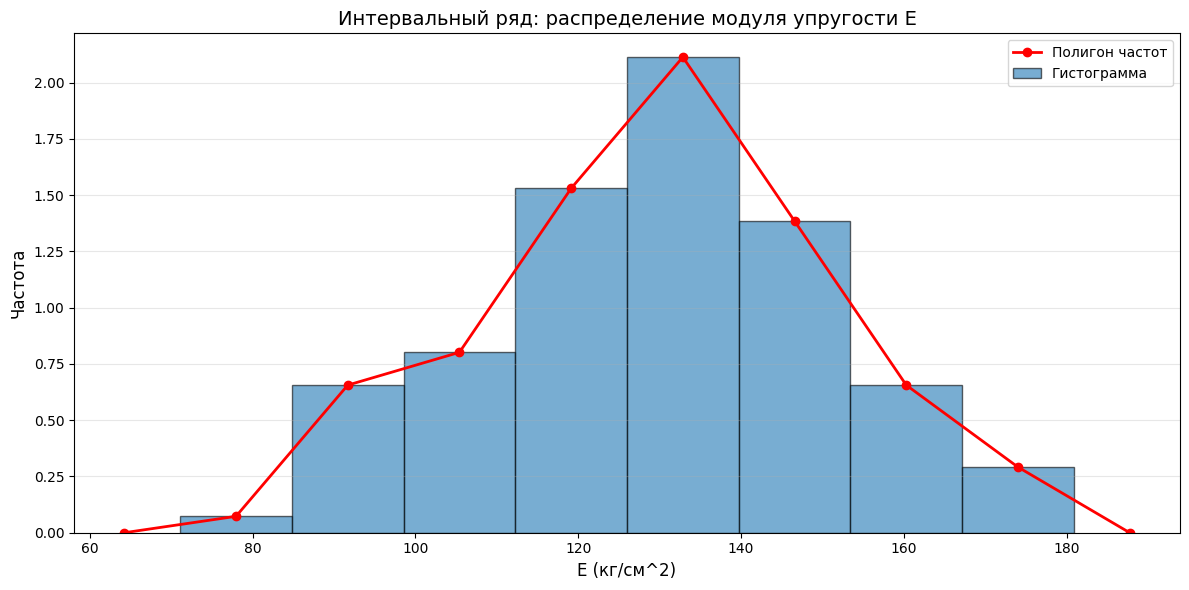

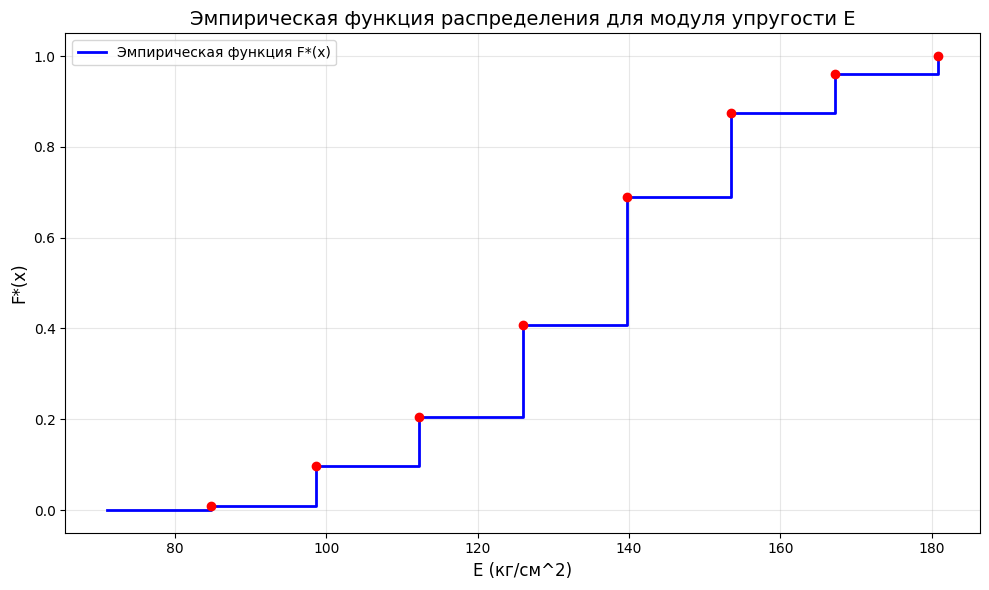

In [ ]:
midpoints_E = interval_df_E['~xi'].values # середины интервалов
frequencies_E = interval_df_E['mi'].values

plt.figure(figsize=(12, 6))

# Гистограмма
plt.bar(midpoints_E, frequencies_E / interval_width, width=interval_width,
        edgecolor='black', alpha=0.6, label='Гистограмма', align='center')

# Полигон частот
x_poly_E = np.concatenate([[midpoints_E[0] - interval_width], midpoints_E, [midpoints_E[-1] + interval_width]])
y_poly_E = np.concatenate([[0], frequencies_E / interval_width, [0]])
plt.plot(x_poly_E, y_poly_E, 'ro-', linewidth=2, markersize=6, label='Полигон частот')

plt.xlabel('E (кг/см^2)', fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title('Интервальный ряд: распределение модуля упругости E', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

# Эмпирическая функция распределения
def parse_right_bound(interval_str):
    clean = interval_str.strip('[])').replace(' ', '')
    left, right = map(float, clean.split('-'))
    return right

right_bounds_E = [parse_right_bound(x) for x in interval_df_E['[xi, xi+1)']]
cum_freq_E = interval_df_E['mi_нак'].values / N

x_ef_E = [right_bounds_E[0] - (right_bounds_E[1] - right_bounds_E[0])] + right_bounds_E
y_ef_E = [0] + list(cum_freq_E)

plt.figure(figsize=(10, 6))
plt.step(x_ef_E, y_ef_E, where='post', linewidth=2, color='blue', label='Эмпирическая функция F*(x)')
plt.plot(right_bounds_E, cum_freq_E, 'ro', markersize=6)

plt.xlabel('E (кг/см^2)', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.title('Эмпирическая функция распределения для модуля упругости E', fontsize=14)
plt.grid(True, alpha=0.3, axis='both')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## Графики для признака E (относительные частоты)


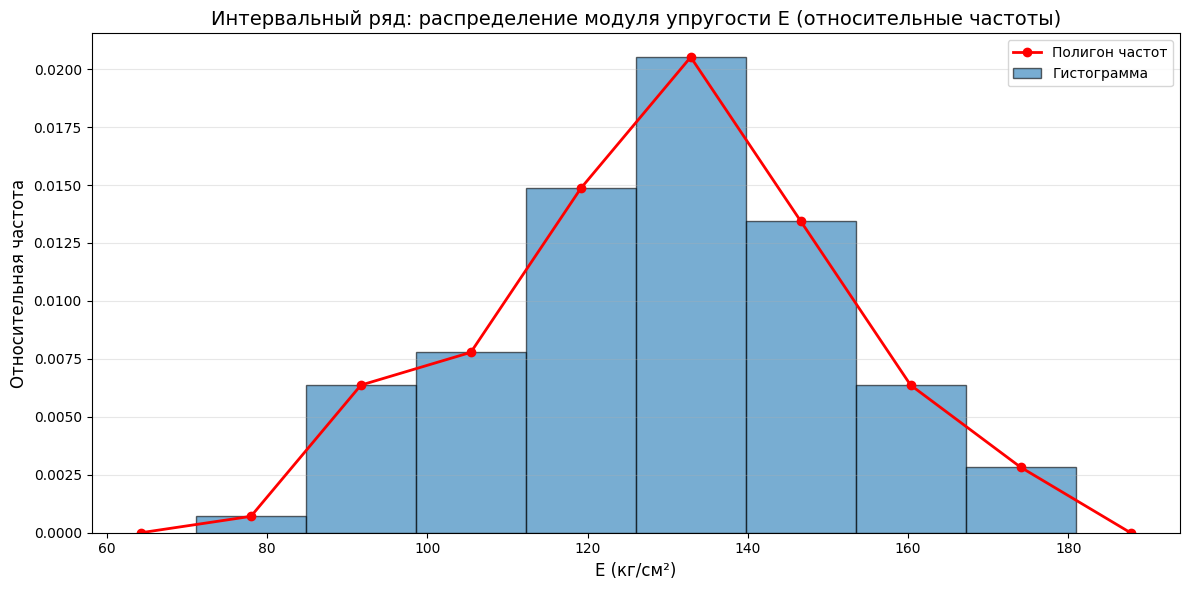

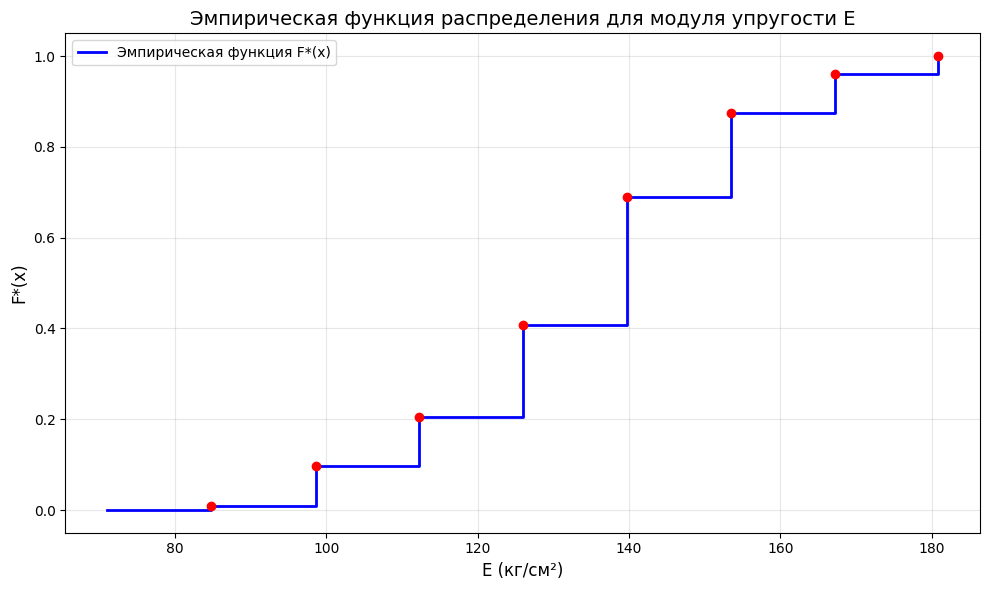

In [ ]:
rel_frequencies_E = interval_df_E['~mi'].values

plt.figure(figsize=(12, 6))

# Гистограмма
plt.bar(midpoints_E, rel_frequencies_E / interval_width, width=interval_width,
        edgecolor='black', alpha=0.6, label='Гистограмма', align='center')

# Полигон частот
x_poly_E_rel = np.concatenate([[midpoints_E[0] - interval_width], midpoints_E, [midpoints_E[-1] + interval_width]])
y_poly_E_rel = np.concatenate([[0], rel_frequencies_E / interval_width, [0]])
plt.plot(x_poly_E_rel, y_poly_E_rel, 'ro-', linewidth=2, markersize=6, label='Полигон частот')

plt.xlabel('E (кг/см²)', fontsize=12)
plt.ylabel('Относительная частота', fontsize=12)
plt.title('Интервальный ряд: распределение модуля упругости E (относительные частоты)', fontsize=14)
plt.grid(True, alpha=0.3, axis='y')
plt.legend()
plt.tight_layout()
plt.show()

# Эмпирическая функция распределения
def parse_right_bound(interval_str):
    clean = interval_str.strip('[])').replace(' ', '')
    left, right = map(float, clean.split('-'))
    return right

right_bounds_E = [parse_right_bound(x) for x in interval_df_E['[xi, xi+1)']]
cum_rel_freq_E = interval_df_E['~mi_нак'].values

x_ef_E_rel = [right_bounds_E[0] - (right_bounds_E[1] - right_bounds_E[0])] + right_bounds_E
y_ef_E_rel = [0] + list(cum_rel_freq_E)

plt.figure(figsize=(10, 6))
plt.step(x_ef_E_rel, y_ef_E_rel, where='post', linewidth=2, color='blue', label='Эмпирическая функция F*(x)')
plt.plot(right_bounds_E, cum_rel_freq_E, 'ro', markersize=6)

plt.xlabel('E (кг/см²)', fontsize=12)
plt.ylabel('F*(x)', fontsize=12)
plt.title('Эмпирическая функция распределения для модуля упругости E', fontsize=14)
plt.grid(True, alpha=0.3, axis='both')
plt.legend()
plt.ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## Точечные оценки для признака E (метод условных вариант)

In [ ]:
x_i_E = interval_df_E['~xi'].values # середины интервалов
n_i_E = interval_df_E['~mi'].values # относительные частоты

h_E = x_i_E[1] - x_i_E[0]
C_idx_E = np.argmax(interval_df_E['mi'].values)
C_E = x_i_E[C_idx_E]

# Условные варианты
u_i_E = np.round((x_i_E - C_E) / h_E).astype(int)

table1_E = pd.DataFrame({
    'i': range(1, k + 1),
    'x_i': np.round(x_i_E, 2),
    'n_i': np.round(n_i_E, 4),
    'u_i': u_i_E,
    '(n_i u_i)': n_i_E * u_i_E,
    '(n_i u_i^2)': n_i_E * u_i_E**2,
    '(n_i u_i^3)': n_i_E * u_i_E**3,
    '(n_i u_i^4)': n_i_E * u_i_E**4,
    '(n_i (u_i + 1)^4)': n_i_E * (u_i_E + 1)**4
})

sum_row_E = {
    'i': 'Σ',
    'x_i': '-',
    'n_i': np.round(table1_E['n_i'].sum(), 4),
    'u_i': '-',
    '(n_i u_i)': np.round(table1_E['(n_i u_i)'].sum(), 4),
    '(n_i u_i^2)': np.round(table1_E['(n_i u_i^2)'].sum(), 4),
    '(n_i u_i^3)': np.round(table1_E['(n_i u_i^3)'].sum(), 4),
    '(n_i u_i^4)': np.round(table1_E['(n_i u_i^4)'].sum(), 4),
    '(n_i (u_i + 1)^4)': np.round(table1_E['(n_i (u_i + 1)^4)'].sum(), 4)
}
table1_E = pd.concat([table1_E, pd.DataFrame([sum_row_E])], ignore_index=True)

print("ТАБЛИЦА №1")
print(table1_E.to_string(index=False))

control_sum = table1_E['(n_i (u_i + 1)^4)'].iloc[-1]
moment_sum = (table1_E['(n_i u_i^4)'].iloc[-1] +
              4 * table1_E['(n_i u_i^3)'].iloc[-1] +
              6 * table1_E['(n_i u_i^2)'].iloc[-1] +
              4 * table1_E['(n_i u_i)'].iloc[-1] + 1)

print(f"\nКонтроль:")
print(f"Sum n_i*(u_i+1)^4 = {control_sum:.4f}")
print(f"Sum n_i*u_i^4 + 4*Sum n_i*u_i^3 + 6*Sum n_i*u_i^2 + 4*Sum n_i*u_i + 1 = {moment_sum:.4f}")
print(f"Разница: {abs(control_sum - moment_sum):.2e}")

# таблица 2
M_star_1_E = table1_E['(n_i u_i)'].iloc[-1]
M_star_2_E = table1_E['(n_i u_i^2)'].iloc[-1]
M_star_3_E = table1_E['(n_i u_i^3)'].iloc[-1]
M_star_4_E = table1_E['(n_i u_i^4)'].iloc[-1]

m_1_E = 0
m_2_E = h_E**2 * (M_star_2_E - M_star_1_E**2)
m_3_E = h_E**3 * (M_star_3_E - 3 * M_star_1_E * M_star_2_E + 2 * M_star_1_E**3)
m_4_E = h_E**4 * (M_star_4_E - 4 * M_star_1_E * M_star_3_E + 6 * M_star_1_E**2 * M_star_2_E - 3 * M_star_1_E**4)

table2_E = pd.DataFrame({
    'k': [1, 2, 3, 4],
    'M*_k': [np.round(M_star_1_E, 4), np.round(M_star_2_E, 4),
             np.round(M_star_3_E, 4), np.round(M_star_4_E, 4)],
    'm_k': [np.round(m_1_E, 4), np.round(m_2_E, 4),
            np.round(m_3_E, 4), np.round(m_4_E, 4)]
})

print("\nТАБЛИЦА №2")
print(table2_E.to_string(index=False))

ТАБЛИЦА №1
i     x_i    n_i u_i  (n_i u_i)  (n_i u_i^2)  (n_i u_i^3)  (n_i u_i^4)  (n_i (u_i + 1)^4)
1   77.96 0.0097  -4    -0.0388       0.1552      -0.6208       2.4832             0.7857
2   91.69 0.0874  -3    -0.2622       0.7866      -2.3598       7.0794             1.3984
3  105.41 0.1068  -2    -0.2136       0.4272      -0.8544       1.7088             0.1068
4  119.14 0.2039  -1    -0.2039       0.2039      -0.2039       0.2039             0.0000
5  132.86 0.2816   0     0.0000       0.0000       0.0000       0.0000             0.2816
6  146.59 0.1845   1     0.1845       0.1845       0.1845       0.1845             2.9520
7  160.31 0.0874   2     0.1748       0.3496       0.6992       1.3984             7.0794
8  174.04 0.0388   3     0.1164       0.3492       1.0476       3.1428             9.9328
Σ       - 1.0001   -    -0.2428       2.4562      -2.1076      16.2010            22.5367

Контроль:
Sum n_i*(u_i+1)^4 = 22.5367
Sum n_i*u_i^4 + 4*Sum n_i*u_i^3 + 6*Sum n_i*u_i^2 

## Выборочные характеристики для признака E

In [ ]:
x_i = interval_df_E['~xi'].values          # середины интервалов
n_i = interval_df_E['~mi'].values          # относительные частоты
m_i = interval_df_E['mi'].values           # абсолютные частоты
bins_E = intervals_E                       # границы интервалов
h = h_E                                    # ширина интервала
N = len(df)                                # объём выборки

x_mean = np.sum(n_i * x_i)
D_v = np.sum(n_i * (x_i - x_mean) ** 2)
sigma_v = np.sqrt(D_v)

M_star_1 = table1_E['(n_i u_i)'].iloc[-1]
x_mean_cond = C_E + h * M_star_1
D_v_cond = m_2_E

print(f"Выборочное среднее x_bar:")
print(f"  Стандартная формула: {x_mean:.4f}")
print(f"  Через условные варианты: {x_mean_cond:.4f}")
print(f"  Разница: {abs(x_mean - x_mean_cond) / x_mean:.2e}\n")

print(f"Выборочная дисперсия D_v:")
print(f"  Стандартная формула: {D_v:.4f}")
print(f"  Через условные варианты: {D_v_cond:.4f}")
print(f"  Разница: {abs(D_v - D_v_cond) / D_v:.2e}\n")

print(f"Выборочное СКО sigma_v: {sigma_v:.4f}\n")

s2 = D_v * N / (N - 1)
s = np.sqrt(s2)

print("Исправленные оценки")
print(f"  s^2 = {s2:.4f}  (смещённая D_v = {D_v:.4f})")
print(f"  s   = {s:.4f}   (смещённая sigma_v = {sigma_v:.4f})")
print(f"  Поправка Бесселя: N/(N-1) = {N/(N-1):.4f}\n")

A_s = m_3_E / (s ** 3)
E_k = m_4_E / (s ** 4) - 3

print("Коэффициенты формы распределения")
print(f"  Асимметрия A_s = {A_s:.4f}")
print(f"  Эксцесс E_k = {E_k:.4f}")

modal_idx = np.argmax(m_i)
n_Mo = m_i[modal_idx]
n_Mo_prev = m_i[modal_idx - 1] if modal_idx > 0 else 0
n_Mo_next = m_i[modal_idx + 1] if modal_idx < len(m_i) - 1 else 0
x_Mo_lower = bins_E[modal_idx]

M_o = x_Mo_lower + h * (n_Mo - n_Mo_prev) / ((n_Mo - n_Mo_prev) + (n_Mo - n_Mo_next))

cum_w = np.cumsum(n_i)
median_idx = np.searchsorted(cum_w, 0.5)
S_prev = cum_w[median_idx - 1] if median_idx > 0 else 0
x_Me_lower = bins_E[median_idx]
n_Me = n_i[median_idx]

M_e = x_Me_lower + h * (0.5 - S_prev) / n_Me

V = s / x_mean_cond * 100

print("\nРобастные характеристики")
print(f"  Мода M_o = {M_o:.4f}")
print(f"  Медиана M_e = {M_e:.4f}")
print(f"  Среднее x_bar = {x_mean_cond:.4f}")
print(f"  Коэффициент вариации V = {V:.2f}%")

print(f"\n1. Среднее значение модуля упругости: {x_mean_cond:.2f} кг/см^2")
print(f"2. Разброс данных (s): {s:.2f} кг/см^2")
print(f"3. Форма распределения: асимметрия = {A_s:.3f}, эксцесс = {E_k:.3f}")
print(f"4. Типичное значение (мода): {M_o:.2f} кг/см^2")
print(f"5. 50% наблюдений не превышают {M_e:.2f} кг/см^2")
print(f"6. Относительная изменчивость: {V:.2f}%")

Выборочное среднее x_bar:
  Стандартная формула: 129.5434
  Через условные варианты: 129.5264
  Разница: 1.32e-04

Выборочная дисперсия D_v:
  Стандартная формула: 451.5789
  Через условные варианты: 451.9122
  Разница: 7.38e-04

Выборочное СКО sigma_v: 21.2504

Исправленные оценки
  s^2 = 456.0061  (смещённая D_v = 451.5789)
  s   = 21.3543   (смещённая sigma_v = 21.2504)
  Поправка Бесселя: N/(N-1) = 1.0098

Коэффициенты формы распределения
  Асимметрия A_s = -0.0923
  Эксцесс E_k = -0.4344

Робастные характеристики
  Мода M_o = 132.1027
  Медиана M_e = 130.4959
  Среднее x_bar = 129.5264
  Коэффициент вариации V = 16.49%

1. Среднее значение модуля упругости: 129.53 кг/см^2
2. Разброс данных (s): 21.35 кг/см^2
3. Форма распределения: асимметрия = -0.092, эксцесс = -0.434
4. Типичное значение (мода): 132.10 кг/см^2
5. 50% наблюдений не превышают 130.50 кг/см^2
6. Относительная изменчивость: 16.49%


# Задание 2

Построить двумерный интервальный вариационный ряд, оформить в виде таблицы.

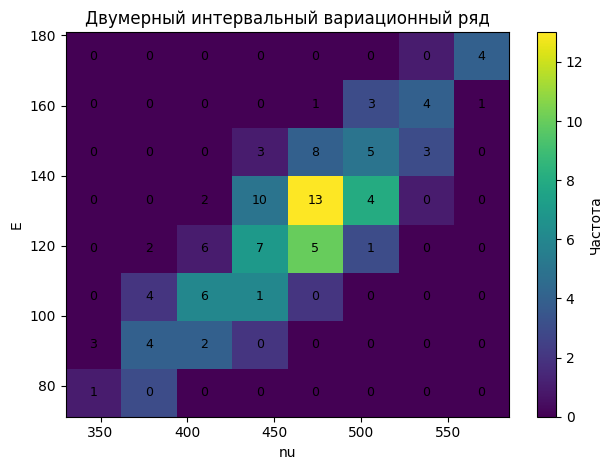

In [ ]:
x = df['nu'].values
y = df['E'].values

# Расчет числа интервалов по формуле Стерджесса
k = round(1 + 3.322 * math.log10(N))

# Двумерный интервальный ряд
H, x_edges, y_edges = np.histogram2d(x, y, bins=k)

# Середины интервалов
x_mid = (x_edges[:-1] + x_edges[1:]) / 2
y_mid = (y_edges[:-1] + y_edges[1:]) / 2

# Транспонируем H, чтобы строки соответствовали Y, столбцы - X
freq_table = H.T.astype(int)

# Вычисление частотных сумм
n_x = freq_table.sum(axis=0)
n_y = freq_table.sum(axis=1)

plt.imshow(freq_table.T, origin='lower', aspect='auto',
           extent=[x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]])
plt.colorbar(label='Частота')
plt.xlabel('nu')
plt.ylabel('E')
plt.title('Двумерный интервальный вариационный ряд')

for i in range(len(x_mid)):
    for j in range(len(y_mid)):
        value = freq_table[j, i]
        text = plt.text(x_mid[i], y_mid[j], str(value),
                       ha='center', va='center', color='black', fontsize=9)

plt.tight_layout()
plt.show()

# Задание 3

По полученному двумерному интервальному вариационному ряду построить корреляционную таблицу, сделать выводы.

In [ ]:
x_labels = [f"{val:.2f}" for val in x_mid]
y_labels = [f"{val:.2f}" for val in y_mid]

corr_table = pd.DataFrame(freq_table, index=y_labels, columns=x_labels)
corr_table['n_y'] = n_y
corr_table.loc['n_x'] = n_x.tolist() + [N]

print("Корреляционная таблица")
print(corr_table)

Корреляционная таблица
        345.94  377.81  409.69  441.56  473.44  505.31  537.19  569.06  n_y
77.96        1       0       0       0       0       0       0       0    1
91.69        3       4       2       0       0       0       0       0    9
105.41       0       4       6       1       0       0       0       0   11
119.14       0       2       6       7       5       1       0       0   21
132.86       0       0       2      10      13       4       0       0   29
146.59       0       0       0       3       8       5       3       0   19
160.31       0       0       0       0       1       3       4       1    9
174.04       0       0       0       0       0       0       0       4    4
n_x          4      10      16      21      27      13       7       5  103


С увеличением значений nu наблюдается тенденция к увеличению значений E, что может говорить о положительной корреляции между признаками. Наибольшая концентрация наблюдений находится в центральной части таблицы, что свидетельствует о группировке данных вокруг средних значений. Компактное расположение частот вдоль диагонали говорит о средней или тесной тесноте корреляционной связи.

# Задание 4

Исходя из результатов корреляционной таблицы вычислить значение выборочного коэффициента корреляции двумя способами: с помощью стандартной формулы и с помощью условных вариант. Убедиться, что результаты совпадают. Сделать выводы.

In [ ]:
# Выборочные средние
x_mean_v = np.sum(n_x * x_mid) / N
y_mean_v = np.sum(n_y * y_mid) / N

# Выборочные СКО
x_std_v = np.sqrt(np.sum(n_x * (x_mid - x_mean_v)**2) / N)
y_std_v = np.sqrt(np.sum(n_y * (y_mid - y_mean_v)**2) / N)

# Двойная сумма
double_sum = 0
for i in range(len(y_mid)):
    for j in range(len(x_mid)):
        double_sum += freq_table[i, j] * y_mid[i] * x_mid[j]

# Коэффициент корреляции
r_standard = (double_sum - N * x_mean_v * y_mean_v) / (N * x_std_v * y_std_v)

# Через условные варианты
C_x_idx = np.argmax(n_x)
C_y_idx = np.argmax(n_y)

C_x = x_mid[C_x_idx]
C_y = y_mid[C_y_idx]

h_x = x_mid[1] - x_mid[0]
h_y = y_mid[1] - y_mid[0]

# Условные варианты
u_i = np.round((x_mid - C_x) / h_x).astype(int)
v_j = np.round((y_mid - C_y) / h_y).astype(int)

# Условные средние
u_mean = np.sum(n_x * u_i) / N
v_mean = np.sum(n_y * v_j) / N

# Условные СКО: sigma_u = sqrt(u^2_mean - u_mean^2)
u2_mean = np.sum(n_x * u_i**2) / N
v2_mean = np.sum(n_y * v_j**2) / N

sigma_u = np.sqrt(u2_mean - u_mean**2)
sigma_v = np.sqrt(v2_mean - v_mean**2)

# Двойная сумма n_ij * u_i * v_j
double_sum_uv = 0
for i in range(len(u_i)):
    for j in range(len(v_j)):
        double_sum_uv += freq_table[i, j] * u_i[i] * v_j[j]

# Коэффициент корреляции через условные варианты
r_conditional = (double_sum_uv - N * u_mean * v_mean) / (N * sigma_u * sigma_v)

print(f"Коэффициент корреляции (выборочные варианты): r = {r_standard:.4f}")
print(f"Коэффициент корреляции (условные варианты): r = {r_conditional:.4f}")
print(f"Разница: {abs(r_standard - r_conditional):.6f}")

Коэффициент корреляции (выборочные варианты): r = 0.8625
Коэффициент корреляции (условные варианты): r = 0.8625
Разница: 0.000000


Значения выборочного коэффициента корреляции, вычисленные двумя способами (по стандартной формуле и через условные варианты), совпали. Это подтверждает корректность проведённых вычислений и инвариантность коэффициента корреляции относительно линейного преобразования шкал.
Полученное значение r = 0.8625 указывает на наличие тесной положительной линейной связи между переменными nu и E: с ростом одного признака второй имеет тенденцию к увеличению.

# Задание 5

Построить доверительный интервал для коэффициента корреляции при уровне значимости $γ\in\{0.95,0.99\}$, сделать выводы.


In [ ]:
# Через условные варианты
r_xy = r_conditional

# Преобразование Фишера
def fisher_z(r):
    return 0.5 * np.log((1 + r) / (1 - r))

def inverse_fisher(z):
    return (np.exp(2 * z) - 1) / (np.exp(2 * z) + 1)

# z для выборочного r
z_bar = fisher_z(r_xy)

# Стандартное отклонение z
sigma_z = 1 / np.sqrt(N - 3)

# Доверительные интервалы
gamma_values = [0.95, 0.99]
lambda_values = {0.95: 1.96, 0.99: 2.576}

print(f"r_xy = {r_xy:.4f}, N = {N}")
print(f"z_bar = {z_bar:.4f}, sigma_z = {sigma_z:.4f}\n")

for gamma in gamma_values:
    lambda_gamma = lambda_values[gamma]

    # Границы интервала для z
    z_lower = z_bar - lambda_gamma * sigma_z
    z_upper = z_bar + lambda_gamma * sigma_z

    # Обратное преобразование Фишера
    r_lower = inverse_fisher(z_lower)
    r_upper = inverse_fisher(z_upper)

    print(f"r_xy принадлежит [{r_lower:.4f}, {r_upper:.4f}] с уровнем значимости = {gamma}")



r_xy = 0.8625, N = 103
z_bar = 1.3028, sigma_z = 0.1000

r_xy принадлежит [0.8029, 0.9049] с уровнем значимости = 0.95
r_xy принадлежит [0.7800, 0.9155] с уровнем значимости = 0.99


Оба интервала не содержат ноль и расположены в области положительных значений, что подтверждает статистическую значимость положительной корреляционной связи между переменными. Расширение доверительного интервала при переходе от γ=0.95 к γ=0.99 соответствует ожидаемому росту надёжности оценки за счёт увеличения её ширины. Нижняя граница даже самого широкого интервала (0.78) указывает на тесную линейную связь между признаками.

#  Задание 6

Осуществить проверку статистической гипотезы о равенстве коэффициента корреляции нулю при заданном уровне значимости $α=0.05$, сделать выводы.

In [ ]:
alpha = 0.05
K = N - 2  # степени свободы

# Вычисление наблюдаемого значения критерия
T_obs = r_xy * math.sqrt(N - 2) / math.sqrt(1 - r_xy**2)

# Нахождение критического значения
t_krit = stats.t.ppf(1 - alpha/2, K)

# Проверка гипотезы
print("Наблюдаемое значение T =", round(T_obs, 4))
print("Критическое значение t =", round(t_krit, 4))

Наблюдаемое значение T = 17.125
Критическое значение t = 1.9837


Так как |T_набл| = 17.125 > t_крит = 1.9837, нулевая гипотеза $H_0$ о равенстве коэффициента корреляции нулю отвергается. Этот результат согласуется с полученным ранее $r_{xy}$ = 0.8625

# Выводы

В ходе работы освоены методы корреляционного анализа двумерных выборок. Получены практические навыки построения корреляционных таблиц, вычисления выборочного коэффициента корреляции (в том числе через условные варианты), построения доверительных интервалов с использованием преобразования Фишера и проверки статистических гипотез о значимости корреляционной связи.

Для исследуемой выборки объёмом $N = 103$ получены следующие результаты:
* Выборочный коэффициент корреляции между признаками $\nu$ и $E$ составил $r_{xy} = 0.8625$, что указывает на тесную положительную линейную связь.
* Доверительный интервал для коэффициента корреляции при $\gamma = 0.95: [0.8029; 0.9049]$ а при $\gamma = 0.99: [0.7800, 0.9155]$. Интервал не содержит ноль, что подтверждает значимость связи.
* Проверка гипотезы $H_0$: $r_{xy} = 0$ при $\alpha = 0.05$ показала статистическую значимость корреляции (T_набл = 17.125 > t_крит = 1.9837).